In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import random
from collections import namedtuple
import matplotlib.cm as cm

from clone_competition_simulation import (
    Gene,
    Parameters,
    FitnessCalculator,
    FixedValue, 
    multiply_fitness,
    replace_fitness,
    PlottingParameters, 
    PopulationParameters,
    TimeParameters,
    FitnessParameters,
    ColourRule, 
    PlotColourMaps,
    FeatureValue, 
    CloneFeature,
    EpistaticEffect
)

import numpy as np

In [2]:
def sim(initial_cells, mutation_rate, max_time, modTrp53=None):
    if modTrp53 == None:
        trp53fitness=TRP53_FITNESS
    else:
        trp53fitness=modTrp53
    
    alleles = [Gene(name='Notch1_allele1', mutation_distribution=FixedValue(NOTCH1_HET_FITNESS), synonymous_proportion=0),
               Gene(name='Notch1_allele2', mutation_distribution=FixedValue(NOTCH1_HET_FITNESS), synonymous_proportion=0),
               Gene(name='Notch2', mutation_distribution=FixedValue(NOTCH2_FITNESS), synonymous_proportion=0),
               Gene(name='Trp53', mutation_distribution=FixedValue(TRP53_FITNESS), synonymous_proportion=0)
              ]

    epistatics = [EpistaticEffect(name='Notch1_hom', gene_names=['Notch1_allele1', 'Notch1_allele2'], fitness_distribution=FixedValue(NOTCH1_HOM_FITNESS)),
                  EpistaticEffect(name='Trp53_Notch1_het1', gene_names=['Notch1_allele1', 'Trp53'], fitness_distribution=FixedValue(NOTCH1_HET_FITNESS)),
                  EpistaticEffect(name='Trp53_Notch1_het2', gene_names=['Notch1_allele2', 'Trp53'], fitness_distribution=FixedValue(NOTCH1_HET_FITNESS)),
                  EpistaticEffect(name='Notch2_Notch1_het1', gene_names=['Notch1_allele1', 'Notch2'], fitness_distribution=FixedValue(NOTCH2_NOTCH1_HET_FITNESS)),
                  EpistaticEffect(name='Notch2_Notch1_het2', gene_names=['Notch1_allele2', 'Notch2'], fitness_distribution=FixedValue(NOTCH2_NOTCH1_HET_FITNESS)),
                  EpistaticEffect(name='Notch2_Trp53', gene_names=['Notch2', 'Trp53'], fitness_distribution=FixedValue(NOTCH2_TRP53_FITNESS)),
                  
                  EpistaticEffect(name='Trp53_Notch1_hom', gene_names=['Notch1_allele1', 'Notch1_allele2', 'Trp53'], fitness_distribution=FixedValue(NOTCH1_HOM_FITNESS)),
                  EpistaticEffect(name='Notch2_Notch1_hom', gene_names=['Notch1_allele1', 'Notch1_allele2', 'Notch2'], fitness_distribution=FixedValue(NOTCH2_NOTCH1_HOM_FITNESS)),
                  EpistaticEffect(name='Notch2_Trp53_Notch1_het1', gene_names=['Notch1_allele1', 'Notch2', 'Trp53'], fitness_distribution=FixedValue(NOTCH2_NOTCH1_HET_FITNESS)),
                  EpistaticEffect(name='Notch2_Trp53_Notch1_het2', gene_names=['Notch1_allele2', 'Notch2', 'Trp53'], fitness_distribution=FixedValue(NOTCH2_NOTCH1_HET_FITNESS)),
                  
                  EpistaticEffect(name='Notch2_Trp53_Notch1_hom', gene_names=['Notch1_allele1', 'Notch1_allele2', 'Trp53', 'Notch2'], fitness_distribution=FixedValue(NOTCH2_NOTCH1_HOM_FITNESS)),
                 ]

    fit_calc = FitnessCalculator(
        genes = alleles,
        combine_mutations = replace_fitness,
        epistatics = epistatics,
        multi_gene_array=True,
    )

    '''p = Parameters(algorithm='WF2D', initial_cells=initial_cells,
                   mutation_generator=mut_gen_epi,
                   mutation_rates=mutation_rate, max_time=max_time,
                   print_warnings=False, division_rate=DIVISION_RATE, samples=NUM_SAMPLES,
                   cell_in_own_neighbourhood=True)'''

    initial_grid = np.zeros((initial_cells,initial_cells), dtype=int)
    p = Parameters(algorithm='WF2D', 
               population=PopulationParameters(initial_grid=initial_grid,cell_in_own_neighbourhood=True),
               times=TimeParameters(max_time=max_time, division_rate=DIVISION_RATE), 
               fitness=FitnessParameters(mutation_rates=mutation_rate,#0.01,
                                     fitness_calculator=fit_calc
                                    )
                  )
    
    s = p.get_simulator()
    s.run_sim()
    return s

In [3]:
# Parameters
NOTCH1_HOM_FITNESS = 7.0

NOTCH1_HET_FITNESS = 2.3
NOTCH2_FITNESS = 1.0
TRP53_FITNESS = 1.6 # taken from inference from TP53 early takeover - note that it varies

NOTCH2_NOTCH1_HET_FITNESS = NOTCH1_HET_FITNESS * 1.1 # estimated from single timepoint takeover 
NOTCH2_NOTCH1_HOM_FITNESS = NOTCH1_HOM_FITNESS * 1.1
NOTCH2_TRP53_FITNESS = TRP53_FITNESS


DIVISION_RATE = 0.27
MUTATION_RATE = 0.000005
NUM_SIMS = 10
NUM_SAMPLES = 200
GRID_SIZE = 1680 #500 ** 2
MAX_TIME = 750 #5000

POPULATION_SIZE = 35

np.random.seed(0)


# Cartoon illustrations

For the purpose of visualisation and explanation.

# Cartoon illustrations

For the purpose of visualisation and explanation.

In [4]:
%%time

s = sim(10, 0.1,10)

14:36:21 | DEBUG | Times rounded to match simulation steps:  Times used: [ 0.          3.7037037   7.40740741 11.11111111]


Output()

CPU times: user 35.3 ms, sys: 11.6 ms, total: 46.9 ms
Wall time: 64 ms


In [5]:
s.times

array([ 0.        ,  3.7037037 ,  7.40740741, 11.11111111])

(0.0, 100.0)

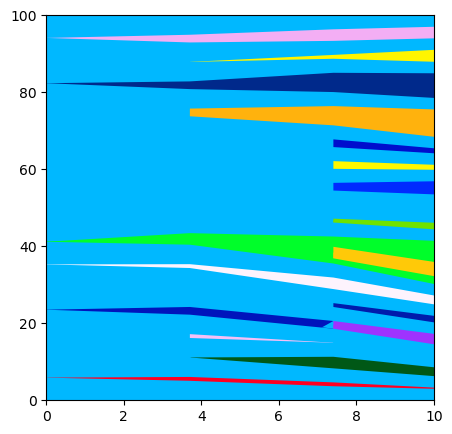

In [6]:

p = s.muller_plot(figsize=(5, 5), allow_y_extension=True, show_mutations_with_x=False);
#help(p)
#ax = p.gca()
#ax.set_ylimit(100)

p.set_ylim([0, 100])

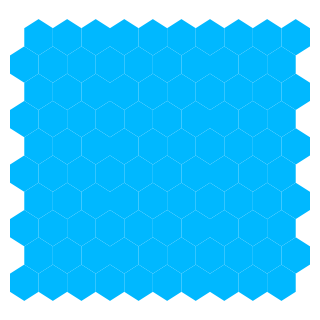

In [7]:
s.plot_grid(t=0, figsize=(3, 3))


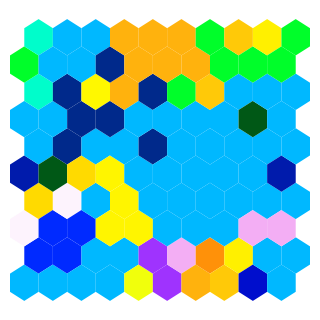

In [8]:
s.plot_grid(grid=s.grid, figsize=(3, 3))


In [9]:
with pd.option_context('display.max_rows', 100, 'display.max_columns', 40):
    display(s.view_clone_info(include_raw_fitness=True))


,clone id,label,fitness,generation born,parent clone id,last gene mutated,Initial clone fitness,Notch1_allele1,Notch1_allele2,Notch2,Trp53,Notch1_hom,Trp53_Notch1_het1,Trp53_Notch1_het2,Notch2_Notch1_het1,Notch2_Notch1_het2,Notch2_Trp53,Trp53_Notch1_hom,Notch2_Notch1_hom,Notch2_Trp53_Notch1_het1,Notch2_Trp53_Notch1_het2,Notch2_Trp53_Notch1_hom
0,0,0,1.00,0,-1,None,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,2.30,1,0,Notch1_allele2,1.0,NaN,2.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,2.30,1,0,Notch1_allele2,1.0,NaN,2.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0,1.60,1,0,Trp53,1.0,NaN,NaN,NaN,1.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0,2.30,1,0,Notch1_allele2,1.0,NaN,2.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,0,1.00,1,0,Notch2,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,0,2.30,1,0,Notch1_allele2,1.0,NaN,2.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,0,1.00,1,0,Notch2,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,0,1.00,1,0,Notch2,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,0,1.60,1,7,Trp53,1.0,NaN,NaN,1.0,1.6,NaN,NaN,NaN,NaN,NaN,1.6,NaN,NaN,NaN,NaN,NaN


In [10]:
s = sim(GRID_SIZE, MUTATION_RATE,MAX_TIME)

14:36:22 | DEBUG | Times rounded to match simulation steps:  Times used: [  0.           7.40740741  14.81481481  22.22222222  29.62962963
  37.03703704  44.44444444  51.85185185  59.25925926  66.66666667
  74.07407407  81.48148148  88.88888889  96.2962963  103.7037037
 111.11111111 118.51851852 125.92592593 133.33333333 140.74074074
 148.14814815 155.55555556 162.96296296 170.37037037 177.77777778
 185.18518519 196.2962963  203.7037037  211.11111111 218.51851852
 225.92592593 233.33333333 240.74074074 248.14814815 255.55555556
 262.96296296 270.37037037 277.77777778 285.18518519 292.59259259
 300.         307.40740741 314.81481481 322.22222222 329.62962963
 337.03703704 344.44444444 351.85185185 359.25925926 366.66666667
 374.07407407 381.48148148 388.88888889 396.2962963  403.7037037
 411.11111111 418.51851852 425.92592593 433.33333333 440.74074074
 448.14814815 455.55555556 462.96296296 470.37037037 477.77777778
 485.18518519 492.59259259 500.         507.40740741 514.81481481
 522.

Output()

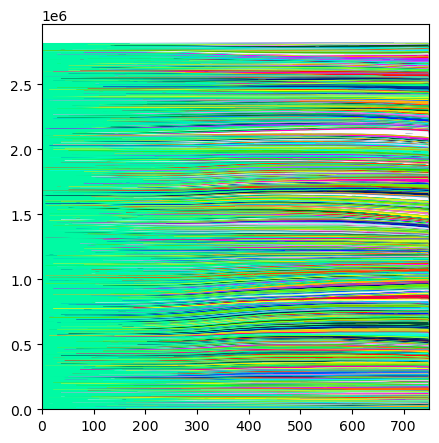

In [11]:
s.muller_plot(figsize=(5, 5), allow_y_extension=True, show_mutations_with_x=False);


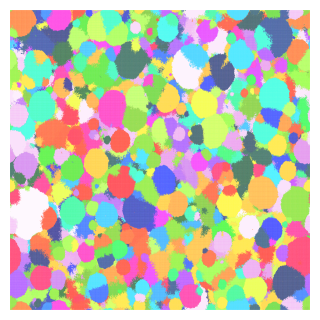

In [12]:
s.plot_grid(grid=s.grid, figsize=(3, 3))


In [13]:
# Define the rule that selects mutant clones and gives them a blue colour
colour_rule1 = ColourRule(
    rule_filter=[  # Define the rule(s) for this clone subset
        FeatureValue(  # This defines a feature and a value
            clone_feature=CloneFeature.INITIAL,   # Whether the clones are initial or not
            value=False  # Here we select the clones that are not initial, i.e. are born from mutations
        )
    ], 
    colourmap=cm.Reds  # Assign a colour map for this clone subset
)
# And now also select non-mutant (initial) clones and given them a red colour
colour_rule2 = ColourRule(
    rule_filter=[  # Define the rule(s) for this clone subset
        FeatureValue(  # This defines a feature and a value
            clone_feature=CloneFeature.INITIAL,   # Whether the clones are initial or not
            value=True  # Here we select the clones that *are* initial
        )
    ], 
    colourmap=cm.Blues  # Assign a colour map for this clone subset
)

# Then define the Plot colours. We are not setting use_fitess=True, so clones will # be given a random colour from the assigned colourmap
plot_colour_maps = PlotColourMaps(
    colour_rules=[colour_rule1, colour_rule2], 
)
s.set_colour_maps(plot_colour_maps)


In [ ]:
s.muller_plot(figsize=(5, 5), show_mutations_with_x=False);


In [ ]:
s.plot_grid(grid=s.grid, figsize=(3, 3))


In [ ]:
colour_rule = ColourRule(
    colourmap=cm.magma
)
# And create a PlotColourMaps object using the colour rule
plot_colour_maps = PlotColourMaps(
    colour_rules=[colour_rule], 
    use_fitness=True
)
s.set_colour_maps(plot_colour_maps)


In [ ]:
s.muller_plot(figsize=(30, 30), show_mutations_with_x=False);


In [ ]:
s.plot_grid(grid=s.grid, figsize=(30, 30))


In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize, to_rgba
import matplotlib.colors as mcolors
# Helper: wrap a fixed hex/named colour as a colourmap callable
def solid_colour(colour):
    rgba = to_rgba(colour)
    return lambda x: rgba

def black(_):
    return((0,0,0,1))

def darkBlue(_):
    return((0,0,0.5,1))

def red(_):
    return((1,0,0,1))

def green(_):
    return((0,1,0,1))

def blue(_):
    return((0,0,1,1))

def darkPurple(_):
    return((1,0,0.5,1))

def purple(_):
    return((1,0,1,1))

def cyan(_):
    return((0,1,1,1))

def darkCyan(_):
    return((0,1,0.5,1))

def grey(_):
    return((1,1,0.5,1))

def white(_):
    return((1,1,1,1))

def yellow(_):
    return((1,1,0,1))

# Map your old Key3 tuples to gene-name sets.
# Old index → gene name:
#   (0,)           = WT            → genes_mutated = set()
#   (0, 1)         = Notch1_a1     → {'Notch1_allele1'}
#   (0, 2)         = Notch1_a2     → {'Notch1_allele2'}
#   (0, 3)         = Notch2        → {'Notch2'}
#   (0, 4)         = Trp53         → {'Trp53'}
#   (0, 1, 2, ...)  = N1 hom       → {'Notch1_allele1', 'Notch1_allele2'}
#   ... etc — substitute your actual gene names below

# Rules are checked in ORDER; more specific (more genes) must come FIRST
colour_rules = [
    # ── 4-gene combinations ─────────────────────────────────────────────
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele1', 'Notch1_allele2', 'Notch2', 'Trp53'})],
        colourmap=white   # Notch2_Trp53_N1hom
    ),
    # ── 3-gene combinations ─────────────────────────────────────────────
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele1', 'Notch2', 'Trp53'})],
        colourmap=grey   # Notch2_Trp53_N1het (via a1)
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele2', 'Notch2', 'Trp53'})],
        colourmap=grey  # Notch2_Trp53_N1het (via a2)
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele1', 'Notch1_allele2', 'Notch2'})],
        colourmap=purple   # Notch2_Notch1_hom
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele1', 'Notch1_allele2', 'Trp53'})],
        colourmap=cyan   # Trp53_Notch1_hom
    ),
    # ── 2-gene combinations ─────────────────────────────────────────────
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele1', 'Notch1_allele2'})],
        colourmap=blue   # Notch1_hom
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele1', 'Notch2'})],
        colourmap=darkPurple   # Notch2_Notch1_het
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele2', 'Notch2'})],
        colourmap=darkPurple   # Notch2_Notch1_het
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele1', 'Trp53'})],
        colourmap=darkCyan   # Trp53_Notch1_het
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele2', 'Trp53'})],
        colourmap=darkCyan   # Trp53_Notch1_het
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch2', 'Trp53'})],
        colourmap=yellow   # Notch2_Trp53
    ),
    # ── 1-gene ──────────────────────────────────────────────────────────
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele1'})],
        colourmap=darkBlue  # Notch1_het
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch1_allele2'})],
        colourmap=darkBlue  # Notch1_het
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Notch2'})],
        colourmap=red    # Notch2
    ),
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value={'Trp53'})],
        colourmap=green    # Trp53
    ),
    # ── WT (no mutations) ───────────────────────────────────────────────
    ColourRule(
        rule_filter=[FeatureValue(clone_feature=CloneFeature.GENES_MUTATED,
                                  value=set())],
        colourmap=black  # WT
    ),
]

my_colour_maps = PlotColourMaps(colour_rules=colour_rules)

s.set_colour_maps(my_colour_maps)


In [ ]:
s.muller_plot(figsize=(30, 30), show_mutations_with_x=False);


In [ ]:
s.plot_grid(grid=s.grid, figsize=(30, 30))
